### What is Middleware in LangChain?
In LangChain, Middleware refers to code that runs before or after your main chain/LLM call. It acts like a layer that can:

* Log requests and responses
* Modify input/output
* Add monitoring / tracing
* Handle errors
* Add authentication
* Measure time (latency)
* Filter or transform data

In [1]:
import os
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")


### Summarization Middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context, Summarization is useful for the following:

* Long-running conversation that exceed context window
* Multi-turn dialogues with extensive history. 
* Applications where preserving full conversation context matters

In [2]:
import sys
sys.path.append("..")
from models import get_model

ppd_model = get_model("ppd")


In [3]:
import sys
sys.path.append("..")
from models import get_model

mli_model = get_model("mli")


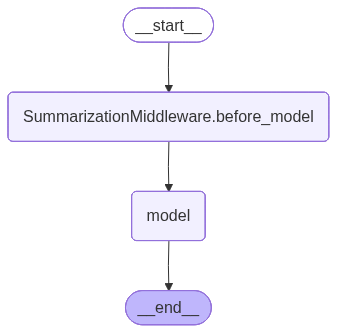

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

llm = mli_model

memory = InMemorySaver()

agent = create_agent(
    model=llm,
    checkpointer=memory,
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)
agent


In [5]:
config = {"configurable":{"thread_id":"test_id"}}

In [6]:
questions=[
    "what is the capital of India",
    "who is the president of India",
    "what comes after 10 in counting",
    "Who does mean  by Apple in Hindi",
    "Number of States in india",
    "First President of India after freedom"
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]}, config)
    print(f"messages: {response}")
    print(f"Messages: {len(response['messages'])}")

messages: {'messages': [HumanMessage(content='what is the capital of India', additional_kwargs={}, response_metadata={}, id='98c3817f-c4d5-45a4-8ada-1b679b567cac'), AIMessage(content='The capital of India is **New\u202fDelhi**. It serves as the seat of the Indian government, housing the President’s residence (Rashtrapati Bhavan), the Parliament, and the Supreme Court, as well as many foreign embassies and major administrative offices.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 71, 'total_tokens': 160, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 25, 'rejected_prediction_tokens': 0, 'text_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'text_tokens': 0, 'image_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': '43806f31', 'id': 'chatcmpl-b0be124a6a95b46e', 'finish_reason': 'stop',

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
import tiktoken  # For accurate token counting

# ========================= TOOL =========================
@tool
def search_hotels(city: str) -> str:
    """Search hotels in a given city. Returns detailed hotel information."""
    return f"""
Hotel in {city}:
1. Grand Hotel - 5 star, $350/night, spa, pool, gym, restaurant
2. Tammana Premium - 4 star, $180/night, gym, rooftop bar
3. Hayat Palace - 3 star, $75/night, clean rooms, near station
4. Royal Inn - 4 star, $220/night, swimming pool, free breakfast
5. Budget Stay - 2 star, $45/night, basic amenities
    """


# ========================= LLM & MEMORY =========================
llm = mli_model

memory = InMemorySaver()

# ========================= MIDDLEWARE =========================
summarization_mw = SummarizationMiddleware(
    model=llm,                    
    trigger=("tokens", 1500),
    keep=("messages", 5)
)

# ========================= CREATE AGENT =========================
agent = create_agent(
    model=llm,
    tools=[search_hotels],
    checkpointer=memory,
    middleware=[summarization_mw]
)

config = {"configurable": {"thread_id": "test_1"}}


# ========================= PROPER TOKEN COUNTER =========================
def count_tokens(messages) -> int:
    """Count tokens accurately using tiktoken"""
    try:
        # Use cl100k_base for GPT-4o / GPT-4 class models
        encoding = tiktoken.get_encoding("cl100k_base")
        total_tokens = 0
        
        for msg in messages:
            content = getattr(msg, "content", str(msg))
            total_tokens += len(encoding.encode(str(content)))
        
        return total_tokens
    except:
        # Fallback: rough estimation
        return sum(len(str(msg.content)) // 4 for msg in messages)


In [8]:
cities = ["Paris", "London", "Mumbai", "Pune", "Delhi", "New York"]

print("🚀 Starting Hotel Search Test with Summarization Middleware...\n")

for i, city in enumerate(cities, 1):
    print(f"📍 Query {i}/6: Finding hotels in {city}...")
    
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find the hotels in {city}")]},
        config=config
    )
    
    messages = response.get("messages", [])
    token_count = count_tokens(messages)
    message_count = len(messages)
    
    print(f"✅ Done! Tokens: ~{token_count} | Messages: {message_count}")
    
    if messages:
        final_message = messages[-1]
        print(f"💬 Final Answer: {final_message.content[:300]}..." if len(final_message.content) > 300 else final_message.content)
    
    print("-" * 80)

🚀 Starting Hotel Search Test with Summarization Middleware...

📍 Query 1/6: Finding hotels in Paris...
✅ Done! Tokens: ~636 | Messages: 4
💬 Final Answer: Here are some options for hotels in Paris, ranging from luxury to budget‑friendly.  I’ve included the star rating, typical nightly price (USD), and a quick snapshot of the main amenities so you can see which might fit your needs.

| # | Hotel | Star Rating | Approx. Price / Night | Key Amenities |
|...
--------------------------------------------------------------------------------
📍 Query 2/6: Finding hotels in London...
✅ Done! Tokens: ~1264 | Messages: 8
💬 Final Answer: Below is a quick overview of the hotels we have for London, spanning luxury to budget‑friendly options.  (All prices are approximate and shown in USD per night.)

| # | Hotel | Star Rating | Approx. Price / Night | Core Amenities |
|---|-------|-------------|-----------------------|----------------|...
----------------------------------------------------------------

### Human in The Loop Middleware (HumanInTheLoopMiddleware)

It allows you to pause the agent before executing sensitive or risky tool calls and let a human review/approve them.



In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
import os

# ========================= TOOL =========================
@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email to a recipient."""
    # In real project, you would call actual email API here (e.g., Gmail, SendGrid)
    print(f"\n📧 === EMAIL SIMULATION ===")
    print(f"To      : {to}")
    print(f"Subject : {subject}")
    print(f"Body    : {body[:200]}..." if len(body) > 200 else body)
    print(f"===========================\n")
    return f"✅ Email successfully sent to {to}"


llm = mli_model

memory = InMemorySaver()

# Create Human-in-the-Loop Middleware
hitl_middleware = HumanInTheLoopMiddleware(
    interrupt_on={
        "send_email": True,  
    }
)

# Create Agent with HITL Middleware
agent = create_agent(
    model=llm,
    tools=[send_email],
    checkpointer=memory,
    middleware=[hitl_middleware]
)

config = {"configurable": {"thread_id": "demo_001"}}


# ========================= HUMAN APPROVAL FUNCTION =========================
def human_approval_loop(response):
    """Handle human decision when agent is interrupted"""
    
    if not response.get("interrupt"):
        return response  # No interrupt, return normally

    print("\n" + "="*60)
    print("🛑 HUMAN APPROVAL REQUIRED")
    print("="*60)

    interrupt_data = response["interrupt"]
    tool_call = interrupt_data.get("tool_call", {})

    print(f"Tool Name : {tool_call.get('name')}")
    print(f"Arguments :")
    for key, value in tool_call.get('args', {}).items():
        print(f"   • {key}: {value}")

    while True:
        print("\nWhat would you like to do?")
        print("1. Approve")
        print("2. Edit & Approve")
        print("3. Reject")
        choice = input("Enter choice (1/2/3): ").strip()

        if choice == "1":
            # Approve as is
            return agent.invoke(None, config=config, interrupt_action="approve")

        elif choice == "2":
            # Edit arguments
            print("\nEnter new values (press Enter to keep original):")
            new_to = input(f"To ({tool_call['args'].get('to')}): ") or tool_call['args'].get('to')
            new_subject = input(f"Subject ({tool_call['args'].get('subject')}): ") or tool_call['args'].get('subject')
            new_body = input(f"Body (first 100 chars): ") or tool_call['args'].get('body')

            new_args = {
                "to": new_to,
                "subject": new_subject,
                "body": new_body
            }
            return agent.invoke(None, config=config, interrupt_action="edit", interrupt_data=new_args)

        elif choice == "3":
            # Reject
            return agent.invoke(None, config=config, interrupt_action="reject")

        else:
            print("Invalid choice. Please try again.")


# ========================= MAIN LOOP =========================
print("Human-in-the-Loop Agent Started (Type 'exit' to quit)\n")

while True:
    user_input = input("You: ")
    if user_input.lower() in ['exit', 'quit']:
        break

    # Invoke Agent
    response = agent.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=config
    )

    # Handle Human Approval if interrupted
    final_response = human_approval_loop(response)

    # Print final AI message
    messages = final_response.get("messages", [])
    if messages:
        print(f"\n🤖 Assistant: {messages[-1].content}")

Human-in-the-Loop Agent Started (Type 'exit' to quit)


🤖 Assistant: **Subject:** Request for Promotion and Salary Review  

**To:** gbe1@3ds.com  

Dear [Manager’s Name],

I hope you are doing well. I am writing to formally express my interest in being considered for a promotion and a corresponding salary adjustment.

Over the past [X] years/months at [Company/Division], I have consistently taken on increasing responsibilities and delivered results that align with our team’s strategic goals. Some highlights of my recent contributions include:

| Initiative | Impact | Outcome |
|------------|--------|---------|
| **Project Alpha** | Led a cross‑functional team of 6 to deliver the product two weeks ahead of schedule | Achieved a 15% cost saving and increased client satisfaction scores by 12% |
| **Process Optimization** | Streamlined the data‑validation workflow using automated scripts | Reduced manual effort by 30% and cut error rates by 25% |
| **Mentorship** | Trained three junior an